# Analyse des données du baccalauréat en France

Ce notebook analyse les données du baccalauréat en France à partir des résultats par académie.  
Grâce à un EDA (fait sur un notebook dédié), un preprocessing et modélisation de Machine Learning  
pour prédire les mentions elle-même.

## Import + configuation

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    f1_score,
    ConfusionMatrixDisplay
)

np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

## Chargement des données déjà nettoyées

In [2]:
path= '../data/clean_dataset.csv'
df = pd.read_csv(path, delimiter=',')

## Construction du dataset de modelisation

Création d'un nouveau dataset (copie du 1er) avec uniquement les colonnes utilisées  
dans notre modèle.

In [3]:
df_ml = df.copy()

column_droped = [ 
    'admis_au_1er_groupe',
    'refuses_au_1er_groupe', 
    'ajournes_passant_les_epreuves_du_rattrapage', 
    'refuses_au_rattrapage',
    'refuses_totaux',
    'admis_au_rattrapage'
]

df_ml = df_ml.drop(columns=column_droped)

Création de colonnes :  
colonne cible avec toutes les mentions  
colonne taux de présence  

In [4]:
column_mention = [
    'mention_tb_avec_les_felicitations',
    'mention_tb_sans_les_felicitations',
    'mention_b',
    'mention_ab', 
    'sans_mention'
]

df_melt = df_ml.melt(
    id_vars=(
        [
            'session',
            'academie', 
            'sexe', 
            'statut_du_candidat',
            'serie',
            'presents',
            'inscrits',
            'admis_totaux']),
    value_vars=(column_mention),
    var_name='mention',
    value_name='nombre'
)

df_melt['taux_presence'] = df_melt['presents'] / df_melt['inscrits']

Mapping de la colonne mention pour une simplier les noms

In [5]:
mapping_mention = {
    'mention_ab': 'AB',
    'sans_mention' : 'sans_mention',
    'mention_b' : 'B',
    'mention_tb_sans_les_felicitations' : 'TB',
    'mention_tb_avec_les_felicitations' : 'TB',
}

df_melt['mention'] = df_melt['mention'].map(mapping_mention)

Distribution de la colonne cible

In [6]:
df_target = df_melt['mention'].value_counts().reset_index().sort_values(by='count')
px.bar(df_target, x='mention', y='count')

## Preprocessing

Séparation de la cible Y des features X

In [7]:
target_name = 'mention'
features = ['session', 'academie', 'sexe', 'statut_du_candidat','serie','taux_presence']

print('Separating labels from features...')
Y = df_melt.loc[:, target_name]
X = df_melt.loc[:, features]
print('...Done.')
print(f'{Y.head(3)}\n')
print(f'{X.head(3)}\n')

print('Dividing into train and test sets...')
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y) 
print('...Done.\n')

Separating labels from features...
...Done.
0    TB
1    TB
2    TB
Name: mention, dtype: object

   session       academie sexe       statut_du_candidat    serie  \
0     2021  aix-marseille    F  enseignement_a_distance  general   
1     2021         amiens    F  enseignement_a_distance  general   
2     2021       besancon    F  enseignement_a_distance  general   

   taux_presence  
0          0.946  
1          1.000  
2          0.962  

Dividing into train and test sets...
...Done.



Détection des colonnes numériques et catégorielles

In [8]:
numeric_features = []
categorical_features = []
for i,t in X.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print('Found numeric features ', numeric_features)
print('\nFound categorical features ', categorical_features)

Found numeric features  ['session', 'taux_presence']

Found categorical features  ['academie', 'sexe', 'statut_du_candidat', 'serie']


Transformation des colonnes catégorielles et numériques  
Application sur train et test set

In [9]:
# Transformer
numeric_transformer = StandardScaler() 
categorical_transformer = OneHotEncoder(drop='first')  

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print('Performing preprocessings on train set...')
print(X_train.head(3))
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:3])

print('\nPerforming preprocessings on test set...')
print(X_test.head(3))
X_test = preprocessor.transform(X_test)  
print('...Done.')
print(X_test[0:3, :])  

Performing preprocessings on train set...
       session       academie sexe       statut_du_candidat             serie  \
26173     2023         nantes    F  enseignement_a_distance          pro_serv   
6892      2025           nice    F  enseignement_a_distance              st2s   
35918     2024  aix-marseille    M                 scolaire  pro_services_men   

       taux_presence  
26173          0.750  
6892           1.000  
35918          0.997  
...Done.
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (3, 51)>
  Coords	Values
  (0, 0)	-0.03574848866220314
  (0, 1)	-0.6882721753084442
  (0, 20)	1.0
  (0, 32)	1.0
  (0, 40)	1.0
  (1, 0)	1.3902836107872054
  (1, 1)	0.48914183006544776
  (1, 21)	1.0
  (1, 32)	1.0
  (1, 44)	1.0
  (2, 0)	0.6772675610625012
  (2, 1)	0.4767234885453538
  (2, 31)	1.0
  (2, 35)	1.0
  (2, 42)	1.0

Performing preprocessings on test set...
       session     academie sexe       statut_du_candidat             serie 

Encodage de la variable cible

In [10]:
labelencoder = LabelEncoder()

print('Encoding labels on train set...')
print(Y_train.head())
Y_train = labelencoder.fit_transform(Y_train)
print('\n...Done.')
print(Y_train[0:3])

print('\nEncoding labels on test set...')
print(Y_test.head())
Y_test = labelencoder.transform(Y_test)
print('\n...Done.')
print(Y_test[0:3])

Encoding labels on train set...
26173              AB
6892               TB
35918    sans_mention
5075               TB
7900               TB
Name: mention, dtype: object

...Done.
[0 2 3]

Encoding labels on test set...
9305               TB
37323    sans_mention
28214              AB
2042               TB
22936               B
Name: mention, dtype: object

...Done.
[2 3 0]


## Modélisation  

Utilisation de 4 modèles :  
- Logistic Regression puis optimisation par Gridsearch  
- Random Forest Classifier puis optimisation par Gridsearch  
- Gadient Boosting Classifier  
- Voting Classifier à partir de 3 modèles :  
Random Forest Classifier  
Logistic Regression  
Gradient Boosting Classifier  

### Modèle : Logistic Regression

In [11]:
# Train model
lr = LogisticRegression(class_weight='balanced', random_state=42)

print('Training model...')
lr.fit(X_train, Y_train)
print('...Done.')

# Predictions on training  and test set
print('Predictions on training set...')
Y_train_pred = lr.predict(X_train)
print('...Done.')

print('Predictions on test set...')
Y_test_pred = lr.predict(X_test)
print('...Done.')

#scores
lr_accuracy_train = accuracy_score(Y_train, Y_train_pred)
lr_accuracy_test = accuracy_score(Y_test, Y_test_pred)
lr_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
lr_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

# Print scores
print(f'accuracy_score on training set : {lr_accuracy_train}') 
print(f'accuracy_score on test set : {lr_accuracy_test}')

print(f'\nf1_score weighted on training set : {lr_f1_train}')
print(f'f1_score weighted on test set : {lr_f1_test}')

Training model...
...Done.
Predictions on training set...
...Done.
Predictions on test set...
...Done.
accuracy_score on training set : 0.24960855949895616
accuracy_score on test set : 0.20902922755741127

f1_score weighted on training set : 0.25301832826477816
f1_score weighted on test set : 0.21455386313065966


#### Optimisation par Gridsearch

In [12]:
# Perform grid search
print('Grid search...')
# Grid of values to be tested
params = {
    'C' : [0.01, 0.1, 1, 10, 100],
    'max_iter' :[200,500,1000]
}
lgridsearch = GridSearchCV(lr, param_grid=params, cv=5, scoring='f1_weighted')  
lgridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {lgridsearch.best_params_}')

#Predict with gridsearch params
best_model = lgridsearch.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

#scores
glr_accuracy_train = accuracy_score(Y_train, Y_train_pred)
glr_accuracy_test = accuracy_score(Y_test, Y_test_pred)
glr_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
glr_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

#  Print scores
print(f'accuracy_score on training set : {glr_accuracy_train}') 
print(f'accuracy_score on test set : {glr_accuracy_test}')
print(f'\nf1_score on training set : {glr_f1_train}')
print(f'f1_score on test set : {glr_f1_test}')


Grid search...
...Done.
Best hyperparameters : {'C': 100, 'max_iter': 200}
accuracy_score on training set : 0.24941283924843424
accuracy_score on test set : 0.20915970772442588

f1_score on training set : 0.25277012394456916
f1_score on test set : 0.21465212291330482


### Modèle : Random Forest Classifier

In [13]:
# Train model
rc = RandomForestClassifier(n_jobs=-1, random_state=42)

print('Training model...')
rc.fit(X_train, Y_train)
print('...Done.')

# Predictions on training and test set
print('Predictions on training set...')
Y_train_pred = rc.predict(X_train)
print('...Done.')

print('Predictions on test set...')
Y_test_pred = rc.predict(X_test)
print('...Done.')

#scores
rc_accuracy_train = accuracy_score(Y_train, Y_train_pred)
rc_accuracy_test = accuracy_score(Y_test, Y_test_pred)
rc_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
rc_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

# Print scores
print(f'\naccuracy_score on training set : {rc_accuracy_train}') 
print(f'accuracy_score on test set : {rc_accuracy_test}')
print(f'\nf1_score weighted on training set : {rc_f1_train}')
print(f'f1_score weighted on test set : {rc_f1_test}')

Training model...
...Done.
Predictions on training set...
...Done.
Predictions on test set...
...Done.

accuracy_score on training set : 0.4092510438413361
accuracy_score on test set : 0.12669624217118997

f1_score weighted on training set : 0.32190453231419525
f1_score weighted on test set : 0.10010930194758888


#### Optimisation par Gridsearch

In [14]:
# Perform grid search
print('Grid search...')
# Grid of values to be tested
params = {
    'n_estimators': [50, 80, 120, 150],
    'max_depth': [6, 8, 10, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rgridsearch = GridSearchCV(rc, param_grid=params, cv=3, scoring='f1_weighted')  
rgridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {rgridsearch.best_params_}')

#Predict with gridsearch params
best_model = rgridsearch.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

#scores
grc_accuracy_train = accuracy_score(Y_train, Y_train_pred)
grc_accuracy_test = accuracy_score(Y_test, Y_test_pred)
grc_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
grc_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

#  Print scores
print(f'\naccuracy_score on training set : {grc_accuracy_train}') 
print(f'accuracy_score on test set : {grc_accuracy_test}')
print(f'\nf1_score on training set : {grc_f1_train}')
print(f'f1_score on test set : {grc_f1_test}')

Grid search...
...Done.
Best hyperparameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 150}

accuracy_score on training set : 0.4000195720250522
accuracy_score on test set : 0.39992171189979125

f1_score on training set : 0.22859060144659546
f1_score on test set : 0.228494742655021


### Modèle : Gradient Boosting Classifier

In [15]:
# Train model
gbc = GradientBoostingClassifier(random_state=42)

print('Training model...')
gbc.fit(X_train, Y_train)
print('...Done.')

# Predictions on training and test set
print('Predictions on training set...')
Y_train_pred = gbc.predict(X_train)
print('...Done.')

print('Predictions on test set...')
Y_test_pred = gbc.predict(X_test)
print('...Done.')

#scores
gbc_accuracy_train = accuracy_score(Y_train, Y_train_pred)
gbc_accuracy_test = accuracy_score(Y_test, Y_test_pred)
gbc_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
gbc_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

# Print scores
print(f'\naccuracy_score on training set : {gbc_accuracy_train}') 
print(f'accuracy_score on test set : {gbc_accuracy_test}')
print(f'\nf1_score on training set : {gbc_f1_train}')
print(f'f1_score on test set : {gbc_f1_test}')

Training model...
...Done.
Predictions on training set...
...Done.
Predictions on test set...
...Done.

accuracy_score on training set : 0.4000195720250522
accuracy_score on test set : 0.39992171189979125

f1_score on training set : 0.22859060144659546
f1_score on test set : 0.228494742655021


### Modèle : Voting Classifier

In [16]:
# Train model
rc = RandomForestClassifier(n_jobs=-1, random_state=42)
lr = LogisticRegression(class_weight='balanced', random_state=42)
gbc = GradientBoostingClassifier(random_state=42)

model = VotingClassifier(
    estimators=[
        ('rr', rc),
        ('lr', lr),
        ('gbc',gbc)
    ],
    voting='soft',   # ou 'hard'
    n_jobs=-1
)

print('Training model...')
model.fit(X_train, Y_train)
print('...Done.')

# Predictions on training and test set
print('Predictions on training set...')
Y_train_pred = model.predict(X_train)
print('...Done.')

print('Predictions on test set...')
Y_test_pred = model.predict(X_test)
print('...Done.')

#scores
voting_c_accuracy_train = accuracy_score(Y_train, Y_train_pred)
voting_c_accuracy_test = accuracy_score(Y_test, Y_test_pred)
voting_c_f1_train = f1_score(Y_train, Y_train_pred, average='weighted')
voting_c_f1_test = f1_score(Y_test, Y_test_pred, average='weighted')

# Print scores
print(f'\naccuracy_score on training set : {voting_c_accuracy_train}') 
print(f'accuracy_score on test set : {voting_c_accuracy_test}')
print(f'\nf1_score on training set : {voting_c_f1_train}')
print(f'f1_score on test set : {voting_c_f1_test}')

Training model...
...Done.
Predictions on training set...
...Done.
Predictions on test set...
...Done.

accuracy_score on training set : 0.4092510438413361
accuracy_score on test set : 0.32606993736951984

f1_score on training set : 0.25004436020185444
f1_score on test set : 0.20012101682770891


## Comparaison des résultats

In [17]:
model_name = [
    'accuracy on train',
    'accuracy on test',
    'f1_score on train',
    'f1_score on test',

]

voting_classifier = [
    voting_c_accuracy_train,
    voting_c_accuracy_test,
    voting_c_f1_train,
    voting_c_f1_test
]

random_forest_classifier = [
    rc_accuracy_train,
    rc_accuracy_test,
    rc_f1_train,
    rc_f1_test
]

gridsearch_random_forest_classifier = [
    grc_accuracy_train,
    grc_accuracy_test,
    grc_f1_train,
    grc_f1_test
]

logsitic_regression = [
    lr_accuracy_train,
    lr_accuracy_test,
    lr_f1_train,
    lr_f1_test
]

gridsearch_logistic_regression = [
    glr_accuracy_train,
    glr_accuracy_test,
    glr_f1_train,
    glr_f1_test
]

gradient_boost_classifier = [
    gbc_accuracy_train,
    gbc_accuracy_test,
    gbc_f1_train,
    gbc_f1_test
]

df_score = pd.DataFrame(
    {
        'model_name' : model_name, 
        'logsitic_regression' : logsitic_regression, 
        'gridsearch_logistic_regression' : gridsearch_logistic_regression, 
        'random_forest_classifier' : random_forest_classifier, 
        'gridsearch_random_forest_classifier' : gridsearch_random_forest_classifier,     
        'gradient_boost_classifier' : gradient_boost_classifier,
        'voting_classifier' : voting_classifier
    }
)
df_score = df_score.set_index('model_name')
display(df_score)

,logsitic_regression,gridsearch_logistic_regression,random_forest_classifier,gridsearch_random_forest_classifier,gradient_boost_classifier,voting_classifier
model_name,,,,,,
accuracy on train,0.250,0.249,0.409,0.400,0.400,0.409
accuracy on test,0.209,0.209,0.127,0.400,0.400,0.326
f1_score on train,0.253,0.253,0.322,0.229,0.229,0.250
f1_score on test,0.215,0.215,0.100,0.228,0.228,0.200


D'après nos résultats, Random Forest Classifier optimisé par gridsearch est le meilleur  
model.   
Meilleur accuracy et f1 score avec un overfit léger !  

## Matrice de confusion du meilleur modèle

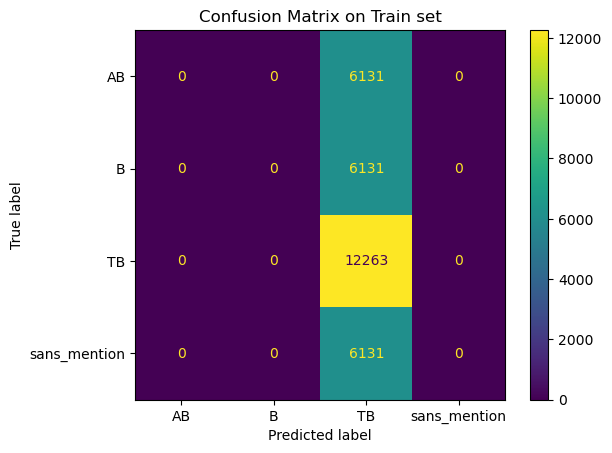

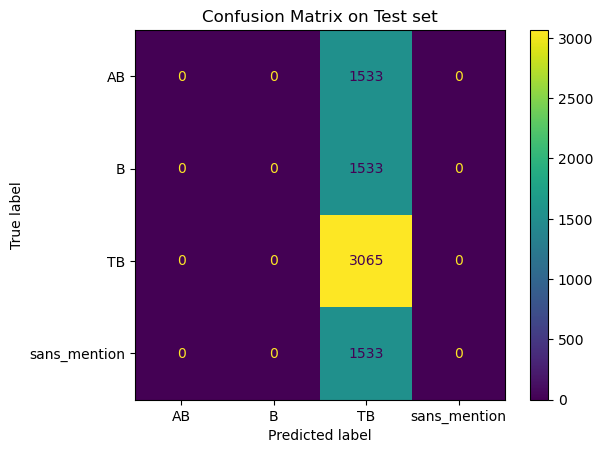

In [18]:
labels = labelencoder.classes_

# Visualize confusion matrices
_, ax = plt.subplots() 
ax.set(title='Confusion Matrix on Train set')  
ConfusionMatrixDisplay.from_estimator(best_model, X_train, Y_train, ax=ax, display_labels=labels)  
plt.show()

_, ax = plt.subplots() 
ax.set(title='Confusion Matrix on Test set')  
ConfusionMatrixDisplay.from_estimator(best_model, X_test, Y_test, ax=ax, display_labels=labels) 
plt.show()

In [25]:
print(pd.Series(Y_train).value_counts(normalize=True))

2   0.400
0   0.200
3   0.200
1   0.200
Name: proportion, dtype: float64


Notre modèle a uniquement tenté de prédire la mention la plus fréquente (TB 40% de nos données).

## Interprétation : Feature importance 

In [19]:
column_names = preprocessor.get_feature_names_out()

Nettoyage du nom des colonnes pour une meilleur lisibilité.

In [24]:
column_names = pd.Series(column_names).str.replace('num__','').str.replace('cat__','')

In [21]:
# Create a pandas DataFrame
feature_importance = pd.DataFrame(
    index=column_names,
    data=rgridsearch.best_estimator_.feature_importances_,
    columns=["feature_importances"],
)
feature_importance = feature_importance.sort_values(by="feature_importances")

Mise en forme graphique des coefficients

In [22]:
fig_feature = px.bar(feature_importance, orientation="h")
fig_feature.update_layout(showlegend=False, margin={"l": 120})
fig_feature.update_layout(autosize=False, width=1200, height=600)
fig_feature.show()

Top 5 des coefficients

In [23]:
feature_importance.sort_values(by="feature_importances", ascending=False).head(5)

,feature_importances
session,0.216
taux_presence,0.170
sexe_M,0.104
statut_du_candidat_individuel,0.042
statut_du_candidat_scolaire,0.040


## Conclusion  

Variables clés : session, taux de présence et sexe.  
Biais potentiels : données agrégées, pas de variables individuelles.  
Les modèles ML montrent des performances modestes dues aux données agrégées (accuracy 0.4 et f1 score 0.2)  
et ne permettent pas de prédire réellement la mention, sans prendre de risque nos modèles  
prédisent la mention majoritaire.
Limites : absence de données individuelles, agrégation par groupes.  
Améliorations possibles : données plus granulaires, features supplémentaires